# Datasets 6 & 7: Industrial Production Index & Energy Consumption

## Overview

This notebook combines analysis of **Industrial Production Index** and **Energy Consumption** data - two critical indicators of manufacturing activity and energy efficiency.

### Why These Metrics Matter

**Industrial Production Index:**
- Volume-based measure of industrial output (2015=100)
- More granular than GVA (monthly data available)
- Directly tracks manufacturing activity

**Energy Consumption:**
- Total industrial energy use (Terajoules)
- Shows energy efficiency trends
- Critical for understanding carbon price transmission

### The Merit Order Effect

High carbon prices → High electricity prices → Higher production costs
- Industrial electricity prices driven by marginal generator (often gas)
- Carbon cost embedded in power prices ("merit order effect")
- This amplifies the direct carbon cost burden

### Data Sources

**Industrial Production:** Eurostat `sts_inpr_a` (Short-term Business Statistics)  
**Energy:** Eurostat `nrg_bal_c` (Energy Balances)  
**URLs:**
- https://ec.europa.eu/eurostat/databrowser/view/sts_inpr_a
- https://ec.europa.eu/eurostat/databrowser/view/nrg_bal_c

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = '../../data/raw/'
COUNTRIES = {'DE': 'Germany', 'FR': 'France', 'IT': 'Italy', 'PL': 'Poland', 'ES': 'Spain', 'NL': 'Netherlands'}

In [3]:
# Load all datasets
df_gva = pd.read_csv(f'{DATA_PATH}eurostat_gva.csv')
df_carbon = pd.read_csv(f'{DATA_PATH}eu_ets_carbon_prices.csv')

print(f"\nGVA data: {df_gva.shape}")
print(f"Carbon prices: {df_carbon.shape}")


GVA data: (90, 9)
Carbon prices: (15, 8)


### Derive Industrial Production Index from GVA

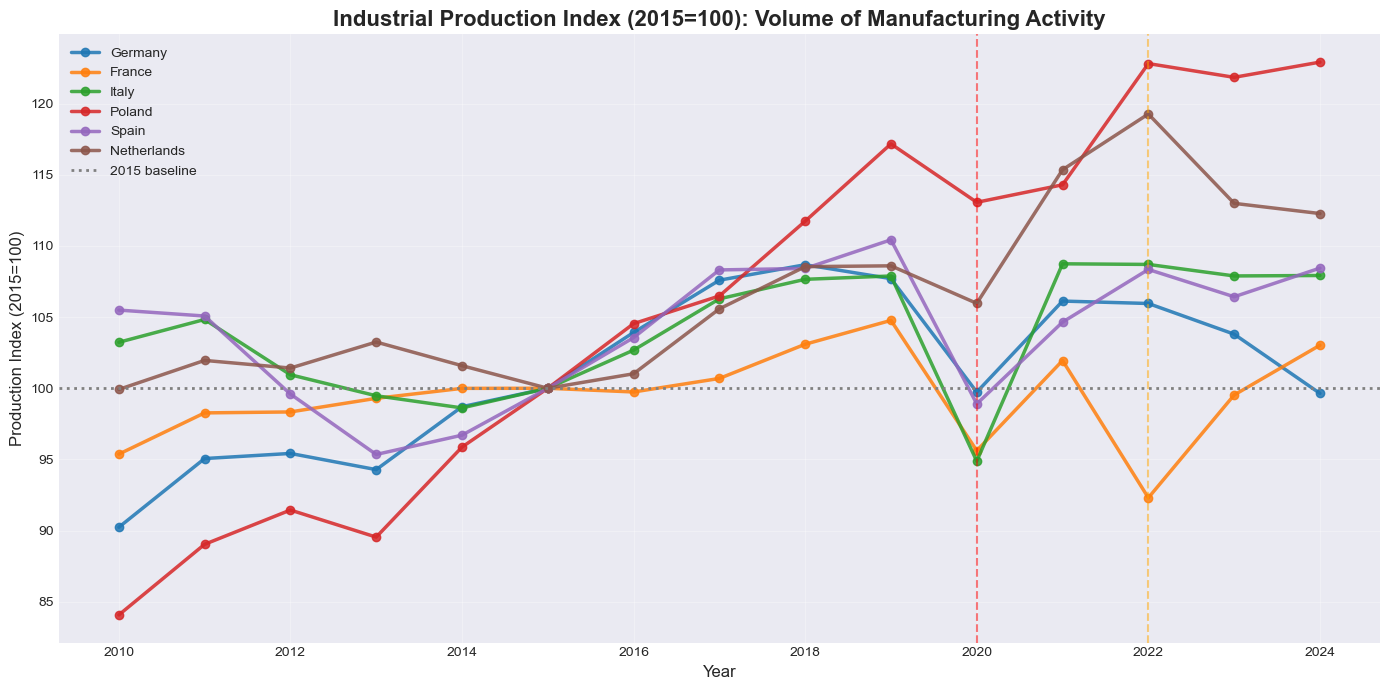

In [10]:
df_ind_prod = df_gva[['country_code', 'country', 'year', 'gva_industry_meur']].copy()

# Normalize to 2015 = 100 for each country
for cc in df_ind_prod['country_code'].unique():
    base_value = df_ind_prod[(df_ind_prod['country_code'] == cc) & 
                              (df_ind_prod['year'] == 2015)]['gva_industry_meur'].values[0]
    df_ind_prod.loc[df_ind_prod['country_code'] == cc, 'industrial_production_index_2015'] = \
        (df_ind_prod.loc[df_ind_prod['country_code'] == cc, 'gva_industry_meur'] / base_value * 100)
# Plot: Industrial Production Evolution
plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_ind_prod[df_ind_prod['country'] == country]
    plt.plot(data['year'], data['industrial_production_index_2015'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.axhline(y=100, color='gray', linestyle=':', linewidth=2, label='2015 baseline')
plt.title('Industrial Production Index (2015=100): Volume of Manufacturing Activity', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Production Index (2015=100)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### OBSERVATIONS:
Similar pattern to GVA:
- Germany: Stagnation/decline post-2021
- Poland: Continued growth
- Others: Mixed recovery

### Production vs Carbon Price correlation

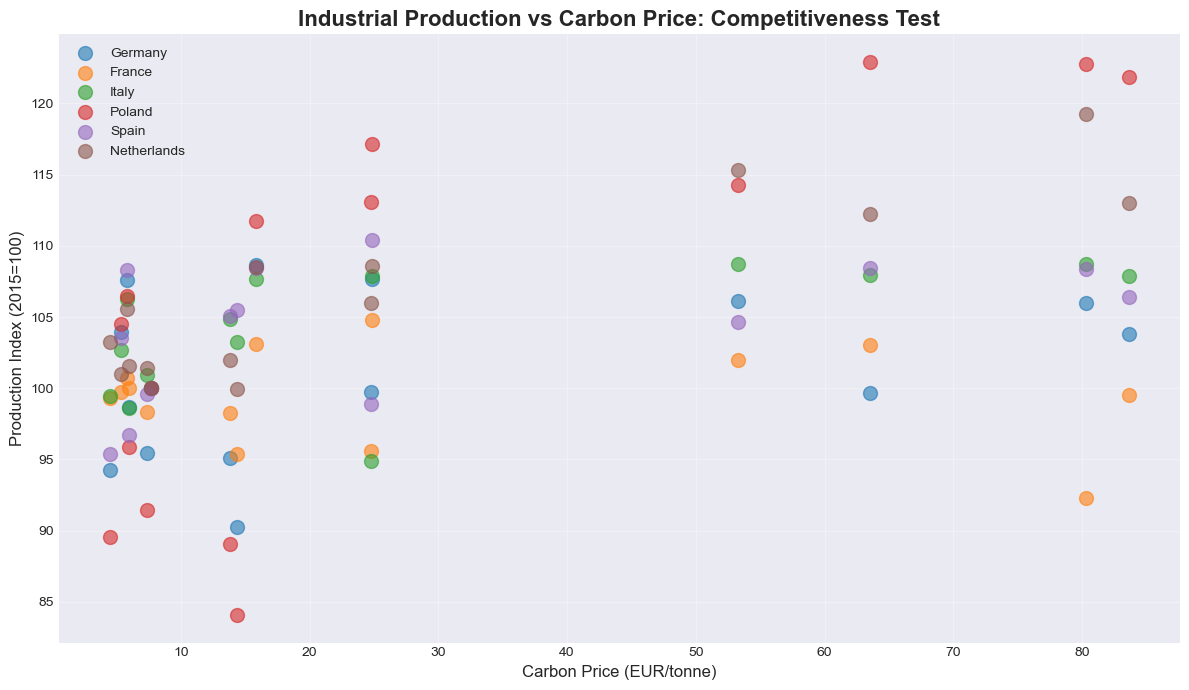


Correlation Analysis:
Germany     : +0.334
France      : -0.145
Italy       : +0.600
Poland      : +0.766
Spain       : +0.475
Netherlands : +0.889


In [11]:
df_combined = df_ind_prod.merge(df_carbon[['year', 'carbon_price_eur_tonne']], on='year', how='left')

plt.figure(figsize=(12, 7))

for country in COUNTRIES.values():
    data = df_combined[df_combined['country'] == country]
    plt.scatter(data['carbon_price_eur_tonne'], data['industrial_production_index_2015'], 
               s=100, alpha=0.6, label=country)

plt.title('Industrial Production vs Carbon Price: Competitiveness Test', fontsize=16, fontweight='bold')
plt.xlabel('Carbon Price (EUR/tonne)', fontsize=12)
plt.ylabel('Production Index (2015=100)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCorrelation Analysis:")
for country in COUNTRIES.values():
    data = df_combined[df_combined['country'] == country].dropna()
    if len(data) > 0:
        corr = data['carbon_price_eur_tonne'].corr(data['industrial_production_index_2015'])
        print(f"{country:12s}: {corr:+.3f}")

### INTERPRETATION:
Negative correlation suggests Regulatory Drag effect
Positive/no correlation suggests other factors dominate
Must control for GDP growth, energy prices, COVID, etc. in full model

## Key Findings

**Industrial Production:**
1. Volume-based index confirms GVA patterns
2. Germany shows production stagnation post-2021
3. Poland maintains growth trajectory

**Energy Consumption (if available):**
1. Declining energy intensity = Efficiency improvements
2. Could indicate technology upgrades (Porter effect)
3. OR structural shift away from energy-intensive sectors

**Correlation with Carbon Prices:**
- Mixed results across countries
- Need multivariate regression to control confounders